In [2]:
!pip show torch

Name: torch
Version: 2.9.1
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: C:\Users\dorian\AppData\Local\pypoetry\Cache\virtualenvs\itpt-lW0Igsa9-py3.13\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: easyocr, torchvision


### WARNING : paddlepaddle-gpu==3.2.2 ne peut pas être utilisé en même temps que pytorch car il n'y a pas de version de pytorch (https://github.com/pytorch/pytorch/blob/main/RELEASE.md#release-compatibility-matrix) qui ait ses dépendances compatibles avec celles de paddlepaddle-gpu==3.2.2 (en particulier CUDNN et NCCL rentre en conflit car soit pytorch a besoin de version trop récentes, soit trop anciennes). Il faut donc réinstaller pytorch pour qu'il réinstalle les bonnes versions de ses dépendances après avoir installé paddlepaddle-gpu==3.2.2 qui les a écrasées pour avoir les bonnes versions pour lui.

In [2]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 86.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 88.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 102.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 63.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 97.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/

In [3]:
!pip uninstall -y paddlepaddle-gpu paddleocr langchain
!pip install paddlepaddle-gpu==3.2.2 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/
!pip install "paddleocr>3.0.0"

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu118/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 GB 739.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.9/699.9 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 5.0 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
  Attempting uninstall: nvidia-nccl-cu11
    Found existing installation: nvidia-nccl-cu11 2.20.5
    Uninstalling nvidia-nccl-cu11-2.20.5:
      Successfully uninstalled nvidia-nccl-cu11-2.20.5
  Attempting uninstall: nvidia-cudnn-cu11
    Found existing installation: nvidia-cudnn-cu11 8.7.0.84
    Uninstalling nvidia-cudnn-cu11-8.7.0.84:
      Successfully uninstalled nvidia-cudnn-cu11-8.7.0.84
ERROR: pip's dependency resolver do

## OCR

In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import glob
import pickle
from paddleocr import PaddleOCR
from tqdm import tqdm

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


### PaddleOCR sur une image

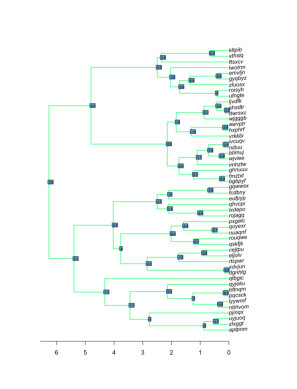

In [ ]:
img_path = "dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_1.png"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
print(paddle.device.get_device())

In [ ]:
ocr = PaddleOCR(lang="en", use_doc_unwarping=False, ocr_version="PP-OCRv5")
results = ocr.predict(image)

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


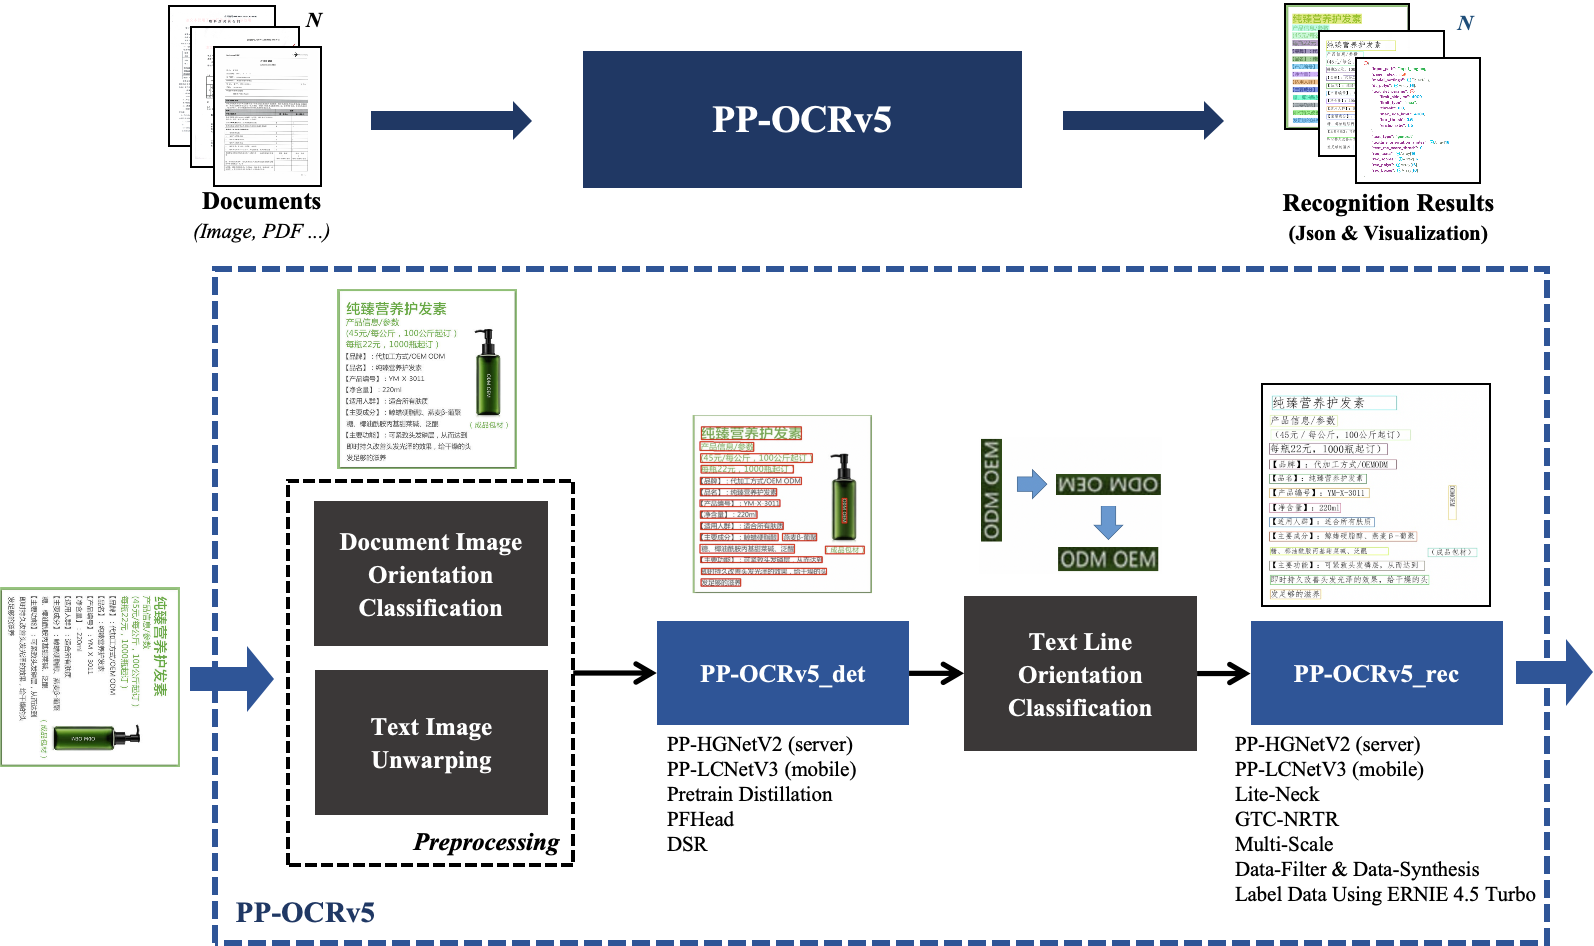

In [ ]:
print(result[0])

{'input_path': None, 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 180, 'rot_img': array([[[  0, ...,   0],
        ...,
        [  0, ...,   0]],

       ...,

       [[  0, ...,   0],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8), 'output_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8)}, 'dt_polys': [array([[653,  34],
       ...,
       [653,  80]], shape=(4, 2), dtype=int16), array([[840,  31],
       ...,
       [840,  79]], shape=(4, 2), dtype=int16), array([[1017,   33],
       ...,
       [1017

In [ ]:
for res in result:
    res.save_to_img("dev/_notebooks/label_extraction_paddleocr_outputs")

In [ ]:
outputs = []

for line in results:
    rec_polys = line.get("rec_polys")
    rec_boxes = line.get("rec_boxes")
    rec_texts = line.get("rec_texts")
    rec_scores = line.get("rec_scores")

    for i, poly in enumerate(rec_polys):
        outputs.append({
            "polygon": rec_polys[i],
            "bbox": rec_boxes[i],
            "text": rec_texts[i],
            "score": rec_scores[i]
        })

In [ ]:
print(outputs)

[{'polygon': array([[1175,  202],
       ...,
       [1177,  241]], shape=(4, 2), dtype=int16), 'bbox': array([1175, ...,  241], shape=(4,), dtype=int16), 'text': 'kltpib', 'score': 0.9328272938728333}, {'polygon': array([[1072,  224],
       ...,
       [1072,  253]], shape=(4, 2), dtype=int16), 'bbox': array([1072, ...,  253], shape=(4,), dtype=int16), 'text': '6.3', 'score': 0.9973090291023254}, {'polygon': array([[1175,  233],
       ...,
       [1177,  272]], shape=(4, 2), dtype=int16), 'bbox': array([1175, ...,  272], shape=(4,), dtype=int16), 'text': 'xthslq', 'score': 0.994307816028595}, {'polygon': array([[808, 246],
       ...,
       [808, 276]], shape=(4, 2), dtype=int16), 'bbox': array([808, ..., 276], shape=(4,), dtype=int16), 'text': '2.9', 'score': 0.8663812279701233}, {'polygon': array([[1176,  269],
       ...,
       [1178,  302]], shape=(4, 2), dtype=int16), 'bbox': array([1176, ...,  302], shape=(4,), dtype=int16), 'text': 'ftsxcv', 'score': 0.9887886643409729}, {'

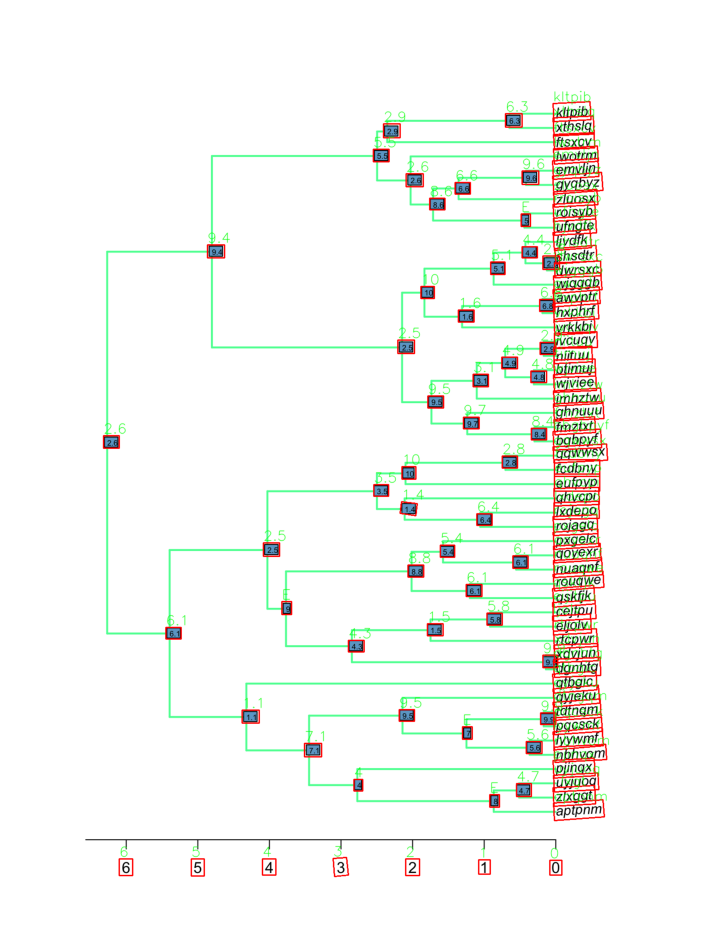

In [ ]:
plt.figure(figsize=(12, 12))
img_show = image.copy()
for item in outputs:
    poly = np.array(item["polygon"], dtype=np.int32)

    #poly[:, 0] = img_show.shape[1] - poly[:, 0]
    #poly[:, 1] = img_show.shape[0] - poly[:, 1]

    text = item["text"]
    cv2.polylines(img_show, [poly], True, (255, 0, 0), 2)
    x, y = poly[0]
    cv2.putText(img_show, text, (int(x), int(y) - 5), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
plt.imshow(img_show)
plt.axis("off")
plt.show()

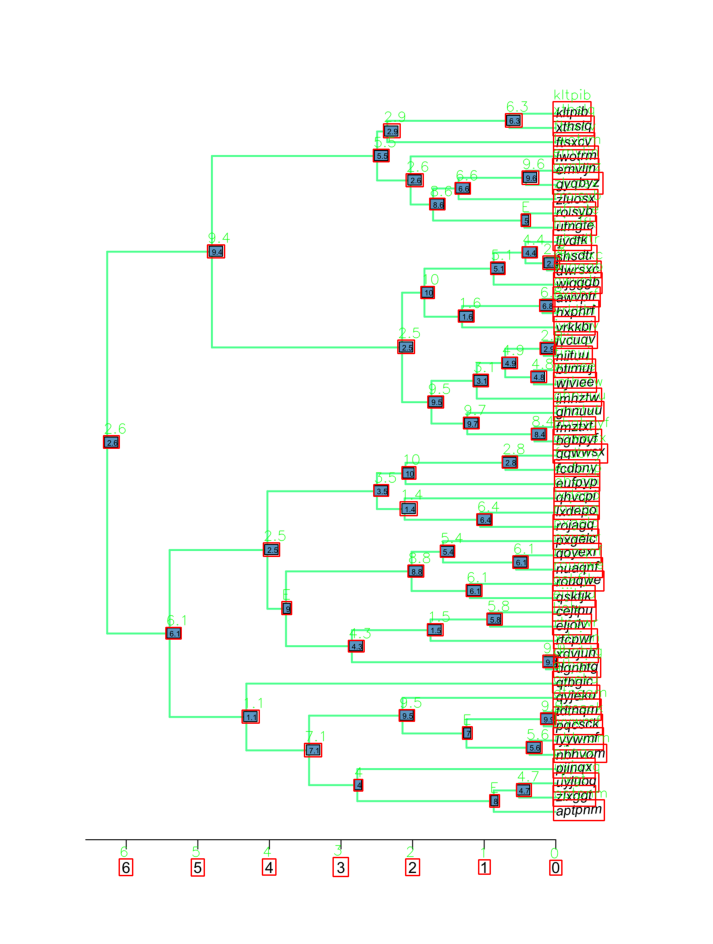

In [ ]:
plt.figure(figsize=(12, 12))
img_show = image.copy()
for item in outputs:
    x1, y1, x2, y2 = item["bbox"]; text = item["text"]

    #x1, x2 = img_show.shape[1] - x1, img_show.shape[1] - x2
    #y1, y2 = img_show.shape[0] - y1, img_show.shape[0] - y2

    cv2.rectangle(img_show, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(img_show, text, (x1, max(y1 - 5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
plt.imshow(img_show)
plt.axis("off")
plt.show()

In [ ]:
filtered_text_boxes = [
    item
    for item in outputs
    if not any(char.isdigit() for char in item["text"])
]

for i, entry in enumerate(filtered_text_boxes[:20], 1):
    print(f"{i}: text='{entry['text']}', score={entry['score']:.2f}, bbox={entry['bbox']}")

1: text='kltpib', score=0.93, bbox=[1175 ...  241]
2: text='xthslq', score=0.99, bbox=[1175 ...  272]
3: text='ftsxcv', score=0.99, bbox=[1176 ...  302]
4: text='Iwotrm', score=0.96, bbox=[1176 ...  333]
5: text='emvljn', score=0.82, bbox=[1174 ...  366]
6: text='gyqbyz', score=1.00, bbox=[1174 ...  398]
7: text='zluosx', score=1.00, bbox=[1176 ...  426]
8: text='rroisyb', score=0.92, bbox=[1175 ...  457]
9: text='E', score=0.90, bbox=[1106 ...  468]
10: text='ufngte', score=1.00, bbox=[1176 ...  487]
11: text='hjvdfk', score=0.74, bbox=[1175 ...  520]
12: text='shsdtr', score=1.00, bbox=[1179 ...  549]
13: text='dwrsxc', score=1.00, bbox=[1178 ...  579]
14: text='wjgggb', score=0.97, bbox=[1176 ...  613]
15: text='awvptr', score=0.83, bbox=[1175 ...  642]
16: text='hxphrf', score=0.95, bbox=[1175 ...  674]
17: text='vrkkbi', score=1.00, bbox=[1177 ...  703]
18: text='ivcuqv', score=0.99, bbox=[1178 ...  732]
19: text='niituu', score=1.00, bbox=[1176 ...  765]
20: text='timuj', score=0

### PaddleOCR sur un ensemble d'images

In [5]:
ocr = PaddleOCR(lang="en", use_doc_unwarping=False, ocr_version="PP-OCRv5")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


In [7]:
image_folder = "dev/_datasets/Tree_PNG_50tips_NOISE_1/images/"
#image_folder = "images/"
image_paths = glob.glob(os.path.join(image_folder, "*.png"))

#image_paths = image_paths[:2]
print(len(image_paths))

1000


In [7]:
all_results = []

for img_path in tqdm(image_paths, desc="OCR images"):
    results = ocr.predict(img_path)
    all_results.extend(results)

print(f"OCR effectué sur {len(image_paths)} images.")

OCR images: 100%|██████████| 1000/1000 [17:38<00:00,  1.06s/it]

OCR effectué sur 1000 images.


In [1]:
outputs = []

for result in all_results:
    input_path = result.get("input_path")
    input_img = cv2.cvtColor(cv2.imread(input_path), cv2.COLOR_BGR2RGB)

    rec_polys = result.get("rec_polys")
    rec_boxes = result.get("rec_boxes")
    rec_texts = result.get("rec_texts")
    rec_scores = result.get("rec_scores")

    for i in range(len(rec_polys)):
        outputs.append({
            "input_path": input_path,
            "input_img": input_img,
            "polygon": rec_polys[i],
            "bbox": rec_boxes[i],
            "text": rec_texts[i],
            "score": rec_scores[i]
        })

print(f"Nombre total de textes détectés : {len(outputs)}")

NameError: name 'all_results' is not defined

In [8]:
outputs = []

for img_path in tqdm(image_paths, desc="OCR images"):
    results = ocr.predict(img_path)

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Impossible de lire {img_path}, skip")
        continue
    input_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    for result in results:
        rec_polys = result.get("rec_polys", [])
        rec_boxes = result.get("rec_boxes", [])
        rec_texts = result.get("rec_texts", [])
        rec_scores = result.get("rec_scores", [])

        for i in range(len(rec_polys)):
            outputs.append({
                "input_path": img_path,
                "input_img": None,
                "polygon": rec_polys[i],
                "bbox": rec_boxes[i],
                "text": rec_texts[i],
                "score": rec_scores[i],
            })

print(f"OCR effectué sur {len(image_paths)} images.")
print(f"Nombre total de textes détectés : {len(outputs)}")

OCR images: 100%|██████████| 1000/1000 [17:28<00:00,  1.05s/it]

OCR effectué sur 1000 images.
Nombre total de textes détectés : 79260


In [ ]:
with open("dev/_notebooks/label_extraction_paddleocr_outputs/ocr_outputs.pkl", "wb") as f:
#with open("ocr_outputs.pkl", "wb") as f:
    pickle.dump(outputs, f)

In [5]:
with open("dev/_notebooks/label_extraction_paddleocr_outputs/ocr_outputs.pkl", "rb") as f:
#with open("ocr_outputs.pkl", "rb") as f:
    outputs = pickle.load(f)

In [70]:
img_names = list(set(os.path.splitext(os.path.basename(item["input_path"]))[0] for item in outputs))
img_names = img_names[:500]

print(f"Nombre d'éléments avant filtrage : {len(outputs)}")

outputs = [item for item in outputs if os.path.splitext(os.path.basename(item["input_path"]))[0] in img_names]

print(f"Nombre d'éléments après filtrage  : {len(outputs)}")


Nombre d'éléments avant filtrage : 79260
Nombre d'éléments après filtrage  : 38912


In [7]:
def update_input_paths(outputs, new_base_path):
    for item in outputs:
        filename = os.path.basename(item["input_path"])
        item["input_path"] = os.path.join(new_base_path, filename)

    return outputs

In [8]:
update_input_paths(outputs, "dev/_datasets/Tree_PNG_50tips_NOISE_1/images/")

[{'input_path': 'dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_470.png',
  'input_img': None,
  'polygon': array([[ 246,  112],
         [1377,  584],
         [ 841, 1897],
         [   0, 1425]], dtype=int16),
  'bbox': array([   0,  112, 1377, 1897], dtype=int16),
  'text': '',
  'score': 0.0},
 {'input_path': 'dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_470.png',
  'input_img': None,
  'polygon': array([[1233,  210],
         [1300,  205],
         [1302,  231],
         [1235,  236]], dtype=int16),
  'bbox': array([1233,  205, 1302,  236], dtype=int16),
  'text': 'dakdrs',
  'score': 0.9999869465827942},
 {'input_path': 'dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_470.png',
  'input_img': None,
  'polygon': array([[1233,  239],
         [1305,  236],
         [1306,  262],
         [1235,  265]], dtype=int16),
  'bbox': array([1233,  236, 1306,  265], dtype=int16),
  'text': 'kusuup',
  'score': 0.9998278617858887},
 {'input_path': 'dev/_datasets/Tree_PNG_

In [4]:
for item in tqdm(outputs, desc="Adding images to outputs"):
    img_bgr = cv2.imread(item["input_path"])
    if img_bgr is None:
        raise RuntimeError(f"Impossible de lire {item['input_path']}.")
    item["input_img"] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

Adding images to outputs:   1%|▏         | 1040/79260 [00:51<1:04:54, 20.09it/s]


KeyboardInterrupt: 

{'input_path': 'dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_6.png', 'input_img': None, 'polygon': array([[1137,  200],
       [1252,  184],
       [1258,  227],
       [1143,  244]], dtype=int16), 'bbox': array([1137,  184, 1258,  244], dtype=int16), 'text': 'dyqvty', 'score': 0.9995118975639343}


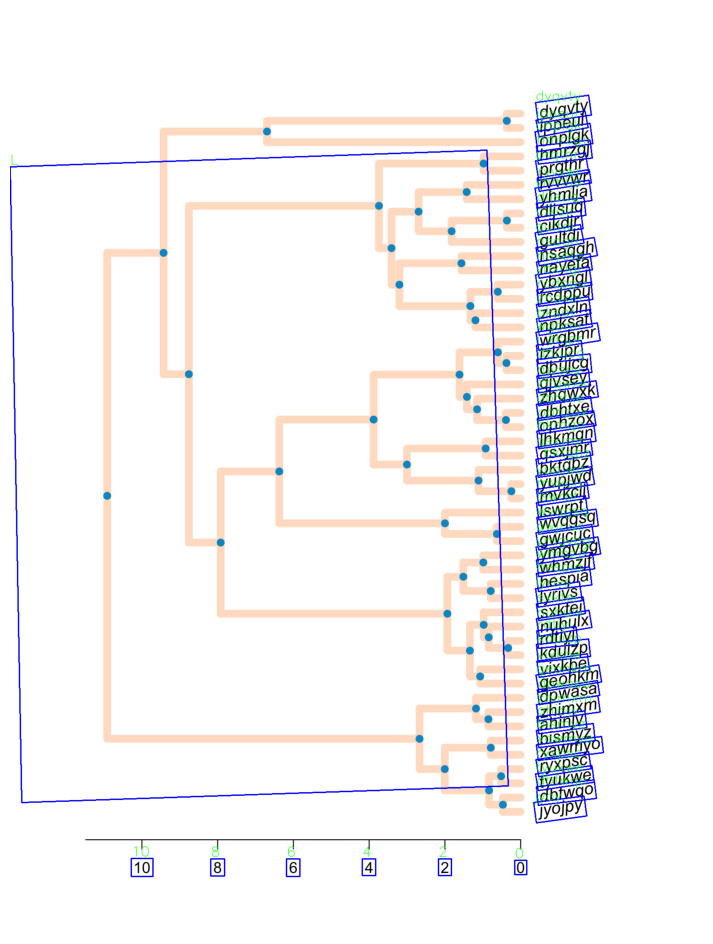

In [33]:
img_path = "Tree_50_6.png"
img_outputs = [item for item in outputs if img_path in os.path.basename(item["input_path"])]

if not img_outputs:
    print(f"Aucun texte trouvé pour {img_path}")
else:
    print(img_outputs[0])

    img_path = img_outputs[0]["input_path"]
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise RuntimeError(f"Impossible de lire {img_path}")
    img_show = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 12))
    for item in img_outputs:
        poly = np.array(item["polygon"], dtype=np.int32)
        text = item["text"]
        cv2.polylines(img_show, [poly], isClosed=True, color=(255, 0, 0), thickness=2)
        x, y = poly[0]
        cv2.putText(img_show, text, (int(x), int(y) - 5), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

## Suppression du texte de l'image en cours

In [23]:
from collections import defaultdict

In [22]:
def build_text_mask(img_shape, ocr_results, kernel_size=(5, 5), dilate_iter=0):
    """
    img_shape   : (H, W, C)
    ocr_results : liste de dicts PaddleOCR avec 'polygon'
    kernel_size : taille du kernel de dilatation
    dilate_iter : nombre d'itérations de dilatation
    """
    mask = np.zeros(img_shape[:2], dtype=np.uint8)

    for item in ocr_results:
        poly = np.array(item["polygon"], dtype=np.int32)
        cv2.fillPoly(mask, [poly], 255)

    if kernel_size is not None and dilate_iter > 0:
        kernel = np.ones(kernel_size, np.uint8)
        mask = cv2.dilate(mask, kernel, iterations=dilate_iter)

    return mask

def remove_text_with_inpainting(img, mask, radius=5, flags=cv2.INPAINT_TELEA):
    """
    img    : image RGB ou BGR
    mask   : masque binaire (255 = zone à supprimer)
    radius : rayon d'inpainting
    flags  : flags cv2
    """
    return cv2.inpaint(
        img,
        mask,
        inpaintRadius=radius,
        flags=flags
    )

### De 1 image

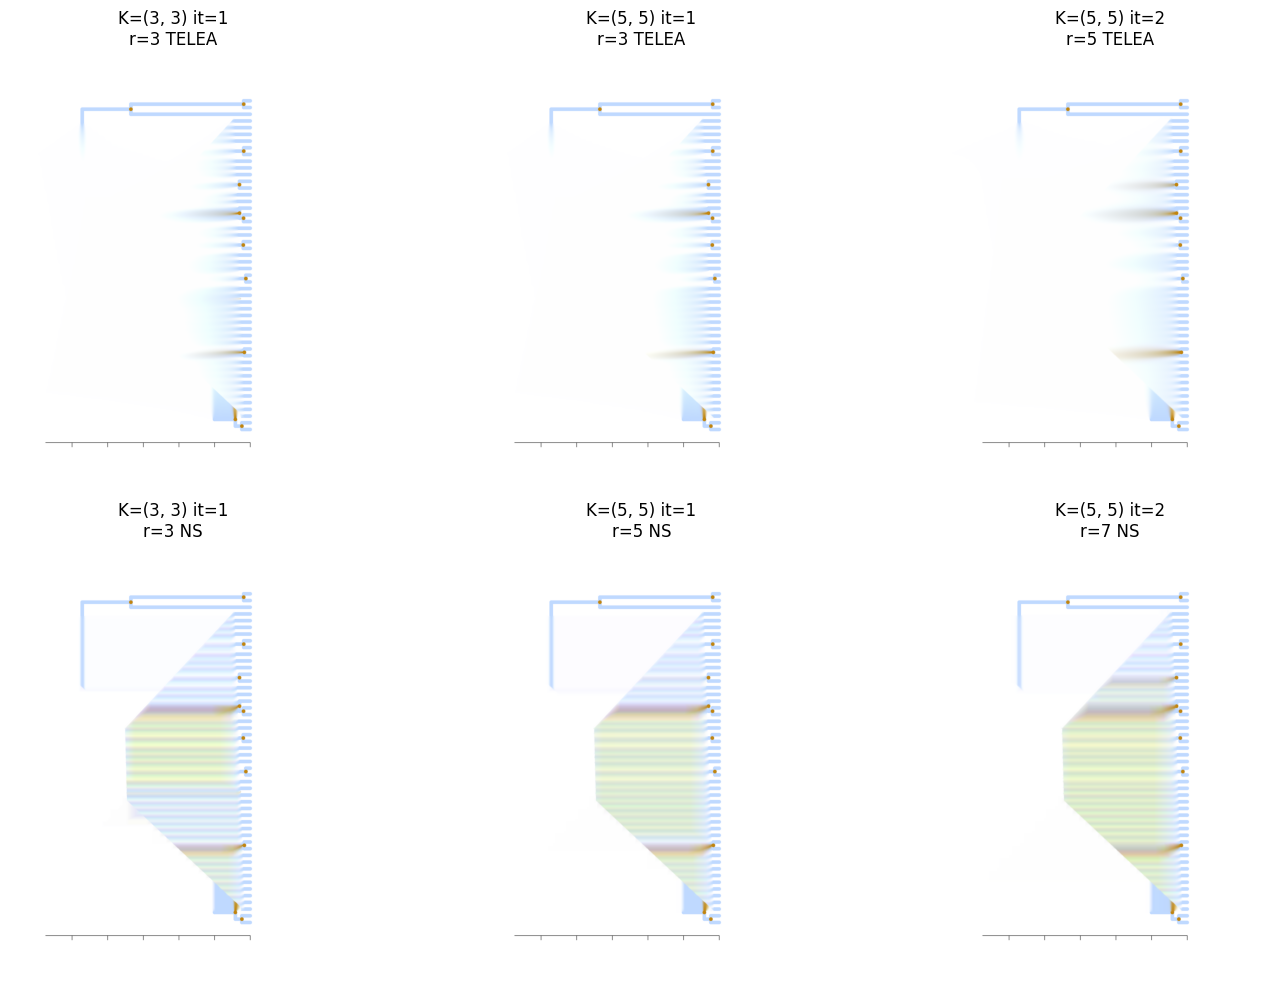

In [32]:
img_name = "Tree_50_6.png"

img_outputs = [item for item in outputs if img_name == os.path.basename(item["input_path"])]

configs = [
    {"kernel": (3, 3), "iter": 1, "radius": 3, "flags": cv2.INPAINT_TELEA},
    {"kernel": (5, 5), "iter": 1, "radius": 3, "flags": cv2.INPAINT_TELEA},
    {"kernel": (5, 5), "iter": 2, "radius": 5, "flags": cv2.INPAINT_TELEA},
    {"kernel": (3, 3), "iter": 1, "radius": 3, "flags": cv2.INPAINT_NS},
    {"kernel": (5, 5), "iter": 1, "radius": 5, "flags": cv2.INPAINT_NS},
    {"kernel": (5, 5), "iter": 2, "radius": 7, "flags": cv2.INPAINT_NS},
]

if not img_outputs:
    print(f"Aucun texte trouvé pour {img_name}")
else:
    img_path = img_outputs[0]["input_path"]
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise RuntimeError(f"Impossible de lire {img_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    n = len(configs)
    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(5 * cols, 5 * rows))

    for i, cfg in enumerate(configs):
        mask = build_text_mask(img_rgb.shape, img_outputs, kernel_size=cfg["kernel"], dilate_iter=cfg["iter"])

        img_no_text = remove_text_with_inpainting(img_rgb, mask, radius=cfg["radius"], flags=cfg["flags"])

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_no_text)
        plt.axis("off")

        flag_name = "TELEA" if cfg["flags"] == cv2.INPAINT_TELEA else "NS"
        plt.title(
            f"K={cfg['kernel']} it={cfg['iter']}\n"
            f"r={cfg['radius']} {flag_name}"
        )

    plt.tight_layout()
    plt.show()

### De N images

In [34]:
OUTPUT_DIR = "dev/_notebooks/label_extraction_paddleocr_outputs/ocr_outputs_img_without_text_55_0_1_TELEA"
os.makedirs(OUTPUT_DIR, exist_ok=True)

KERNEL_SIZE = (5, 5)
DILATE_ITER = 0
INPAINT_RADIUS = 1
INPAINT_FLAG = cv2.INPAINT_TELEA

In [26]:
outputs_by_image = defaultdict(list)
for item in outputs:
    outputs_by_image[item["input_path"]].append(item)

In [35]:
outputs_img_without_text = []
for input_path, img_outputs in tqdm(outputs_by_image.items(), desc="Removing text from images"):

    if not os.path.exists(input_path):
        print(f"[WARN] Image introuvable : {input_path}")
        continue

    img_name = os.path.basename(input_path)
    output_path = os.path.join(OUTPUT_DIR, img_name)

    if os.path.exists(output_path):
        print(f"[SKIP] Image déjà traitée : {img_name}")
        continue

    img_bgr = cv2.imread(input_path)
    if img_bgr is None:
        print(f"[WARN] Impossible de lire : {input_path}")
        continue

    mask = build_text_mask(
        img_shape=img_bgr.shape,
        ocr_results=img_outputs,
        kernel_size=KERNEL_SIZE,
        dilate_iter=DILATE_ITER
    )

    img_no_text = remove_text_with_inpainting(
        img=img_bgr,
        mask=mask,
        radius=INPAINT_RADIUS,
        flags=INPAINT_FLAG
    )

    cv2.imwrite(output_path, img_no_text)

    outputs_img_without_text.append({
        "input_path": input_path,
        "input_img": None,
        "output_path": output_path,
        "output_img": None
    })

Removing text from images: 100%|████████████████████████████████████████████████████████████████████████| 1000/1000 [02:22<00:00,  7.00it/s]


## Labelling

### 1

In [62]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import csv
import re
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
# V1

class PhyloLabelClassifier(nn.Module):
    def __init__(self, geo_feat_dim: int):
        super().__init__()

        # Backbone pour image globale
        self.global_cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.global_cnn.fc = nn.Identity() # sortie: 512, on utilise ResNet comme extracteur de features, pas comme classifieur

        # Backbone pour crop texte
        self.crop_cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.crop_cnn.fc = nn.Identity() # sortie: 512

        # Projection des features géométriques
        self.geo_fc = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.LayerNorm(64) # sortie: 64
        )

        # MLP de fusion
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1) # binaire
        )

    def forward(self, global_img, crop_img, geo_feats):
        """
        global_img : (B, 3, H, W)
        crop_img   : (B, 3, h, w)
        geo_feats  : (B, geo_feat_dim)
        """

        # Rôle : capturer la structure globale de l'arbre phylogénétique
        global_feat = self.global_cnn(global_img) # (B, 512)

        # Rôle : capturer le contexte local du texte
        crop_feat = self.crop_cnn(crop_img) # (B, 512)

        # Rôle : encoder des informations numériques déjà connues
        geo_feat = self.geo_fc(geo_feats) # (B, 64)

        # Rôle : fusionner toutes les informations
        fused = torch.cat([global_feat, crop_feat, geo_feat], dim=1) # (B, 1088)

        logits = self.classifier(fused) # (B, 1)

        return logits.squeeze(1) # (B, 1) -> (B,) (nécessaire pour être compatible avec BCEWithLogitsLoss)

In [ ]:
# V2

class PhyloLabelClassifier(nn.Module):
    def __init__(self, geo_feat_dim: int):
        super().__init__()

        # Backbone pour image globale
        self.global_cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.global_cnn.fc = nn.Linear(512, 128) # sortie: 128, on utilise ResNet comme extracteur de features, pas comme classifieur

        # Backbone pour crop texte
        self.crop_cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.crop_cnn.fc = nn.Linear(512, 128) # sortie: 128

        # Projection des features géométriques
        self.geo_fc = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.LayerNorm(64) # sortie: 64
        )

        # MLP de fusion
        self.classifier = nn.Sequential(
            nn.Linear(128+64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1) # sortie: binaire
        )

    def forward(self, global_img, crop_img, geo_feats):
        """
        global_img : (B, 3, H, W)
        crop_img   : (B, 3, h, w)
        geo_feats  : (B, geo_feat_dim)
        """

        # Rôle : capturer la structure globale de l'arbre phylogénétique
        global_feat = self.global_cnn(global_img) # (B, 128)

        # Rôle : capturer le contexte local du texte
        crop_feat = self.crop_cnn(crop_img) # (B, 128)

        # Rôle : encoder des informations numériques déjà connues
        geo_feat = self.geo_fc(geo_feats) # (B, 64)

        # Rôle : fusionner toutes les informations
        #fused = torch.cat([global_feat, crop_feat, geo_feat], dim=1) # (B, 128+128+64)
        fused = torch.cat([crop_feat, geo_feat], dim=1) # (B, 128+64)

        logits = self.classifier(fused) # (B, 1)

        return logits.squeeze(1) # (B, 1) -> (B,) (nécessaire pour être compatible avec BCEWithLogitsLoss)

In [ ]:
class PhyloTextDataset(Dataset):
    """
    Dataset PyTorch des textes détectés.
    Chaque item contient :
    - global_img : image complète
    - crop_img   : crop autour du texte (bbox élargie)
    - geo_feats  : vecteur avec des données géométrique
    - label      : 0 ou 1 (1 si le texte est présent dans les labels de l'arbre)
    """

    def __init__(self, outputs, labels, crop_scale=6):
        """
        outputs : liste de dictionnaires {input_path, img, polygon, bbox, text, score}
        labels  : dictionnaire {img_name: set(label_texts)}
        """
        self.items = []
        self.crop_scale = crop_scale

        for item in tqdm(outputs, desc="Generating dataset"):
            input_path = item["input_path"]
            if not os.path.exists(input_path):
                continue

            img_base = os.path.basename(input_path)
            img_name = os.path.splitext(img_base)[0]

            image_labels = labels.get(img_name, set())
            label = 1 if item["text"] in image_labels else 0

            # Stocke uniquement les infos nécessaires pour le chargement à la volée
            self.items.append({
                "input_path": input_path,
                "bbox": item["bbox"],
                "text": item["text"],
                "label": label
            })

        print(f"Dataset construit : {len(self.items)} items.")

    @staticmethod
    def get_enlarged_crop(img, bbox, scale=6):
        """
        img   : image NumPy (H,W,C)
        bbox  : [x_min, y_min, x_max, y_max]
        scale : facteur d'agrandissement

        Retourne un crop élargi, sans dépasser l'image.
        """
        H, W, _ = img.shape
        x_min, y_min, x_max, y_max = bbox

        # Centre du bbox
        x_c = (x_min + x_max) / 2
        y_c = (y_min + y_max) / 2

        # Taille originale
        w = x_max - x_min
        h = y_max - y_min

        # Nouvelle taille
        new_w = w * scale
        new_h = h * scale

        # Nouvelles coordonnées
        x_min_new = int(max(x_c - new_w/2, 0))
        x_max_new = int(min(x_c + new_w/2, W))
        y_min_new = int(max(y_c - new_h/2, 0))
        y_max_new = int(min(y_c + new_h/2, H))

        return img[y_min_new:y_max_new, x_min_new:x_max_new].copy()

    @staticmethod
    def compute_geo_features(bbox, img_shape):
        """
        bbox      : [x_min, y_min, x_max, y_max]
        img_shape : tuple (H, W, C) de l'image

        Retourne un vecteur de features normalisées.
        """
        x_min, y_min, x_max, y_max = bbox
        img_h, img_w = img_shape[:2]

        x_min = float(x_min)
        y_min = float(y_min)
        x_max = float(x_max)
        y_max = float(y_max)
        img_w = float(img_w)
        img_h = float(img_h)

        # Centre du bbox
        x_c = (x_min + x_max) / 2
        y_c = (y_min + y_max) / 2

        # Taille
        width  = x_max - x_min
        height = y_max - y_min

        # Position et taille normalisées
        x_center = x_c / img_w
        y_center = y_c / img_h
        width_n  = width / img_w
        height_n = height / img_h

        # Aspect ratio
        aspect_ratio = width / height if height > 0 else 0

        # Surface relative
        area = (width * height) / (img_w * img_h)

        # Distance au centre
        dist_center = np.sqrt((x_center - 0.5)**2 + (y_center - 0.5)**2)

        # Distance aux bords
        dist_left   = x_min / img_w
        dist_top    = y_min / img_h
        dist_right  = 1 - x_max / img_w
        dist_bottom = 1 - y_max / img_h

        # Diagonale de l'image pour distance relative
        diag_len = np.sqrt(img_w**2 + img_h**2)
        bbox_center_dist_diag = np.sqrt((x_c)**2 + (y_c)**2) / diag_len

        return [
            x_center, y_center,
            width_n, height_n,
            aspect_ratio, area,
            dist_center,
            dist_left, dist_top, dist_right, dist_bottom,
            bbox_center_dist_diag
        ]

    @staticmethod
    def img_to_tensor(img, size=(1024, 1024)):
        img = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        return img

    def balance_classes(self, pos_ratio=0.5):
        """
        Rééchantillonne le dataset pour obtenir un ratio approximatif
        de positifs/négatifs donné.

        pos_ratio : proportion de positifs dans le dataset final
        """
        np.random.seed(42)

        pos_items = [item for item in self.items if item["label"] == 1]
        neg_items = [item for item in self.items if item["label"] == 0]

        n_pos = len(pos_items)
        n_neg = len(neg_items)

        total_target = int(n_pos / pos_ratio)
        n_neg_target = total_target - n_pos

        if n_neg_target < n_neg:
            neg_items = list(np.random.choice(neg_items, size=n_neg_target, replace=False))
        else:
            neg_items = list(np.random.choice(neg_items, size=n_neg_target, replace=True))

        self.items = pos_items + neg_items
        np.random.shuffle(self.items)

        print(f"Dataset rééquilibré : {len(pos_items)} positifs, {len(neg_items)} négatifs (ratio ≈ {pos_ratio})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]

        # Charger l'image à la volée
        img_bgr = cv2.imread(item["input_path"])
        if img_bgr is None:
            raise FileNotFoundError(f"Image not found: {item['input_path']}")
        input_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        crop_img = self.get_enlarged_crop(input_img, item["bbox"], scale=self.crop_scale)

        global_img = self.img_to_tensor(input_img, size=(512, 512))
        crop_img   = self.img_to_tensor(crop_img, size=(256, 256))
        geo_feats = torch.tensor(self.compute_geo_features(item["bbox"], input_img.shape), dtype=torch.float32)
        label      = torch.tensor(item["label"], dtype=torch.float32)

        return global_img, crop_img, geo_feats, label

In [73]:
def train_model(model, train_loader, val_loader, device="cpu", epochs=10, lr=1e-4, save_dir="model_checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "train_TP": [], "train_TN": [], "train_FP": [], "train_FN": [],
        "val_loss": [], "val_acc": [], "val_f1": [],
        "val_TP": [], "val_TN": [], "val_FP": [], "val_FN": []
    }

    for epoch in range(epochs):
        # Training
        model.train()
        all_preds, all_labels = [], []
        train_loss = 0
        for _, (global_imgs, crop_imgs, geo_feats, labels) in enumerate(tqdm(train_loader, desc="Training")):
            global_imgs = global_imgs.to(device)
            crop_imgs = crop_imgs.to(device)
            geo_feats = geo_feats.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(global_imgs, crop_imgs, geo_feats)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(labels)

            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        epoch_loss = train_loss / len(train_loader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds)
        tn, fp, fn, tp = confusion_matrix(all_labels, all_preds, labels=[0,1]).ravel()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, F1: {epoch_f1:.4f} | TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["train_f1"].append(epoch_f1)
        history["train_TP"].append(tp)
        history["train_TN"].append(tn)
        history["train_FP"].append(fp)
        history["train_FN"].append(fn)

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0
        with torch.no_grad():
            for _, (global_imgs, crop_imgs, geo_feats, labels) in enumerate(tqdm(val_loader, desc="    Validation")):
                global_imgs = global_imgs.to(device)
                crop_imgs = crop_imgs.to(device)
                geo_feats = geo_feats.to(device)
                labels = labels.to(device)

                logits = model(global_imgs, crop_imgs, geo_feats)
                loss = criterion(logits, labels)
                val_loss += loss.item() * len(labels)

                preds = (torch.sigmoid(logits) > 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds)
        tn, fp, fn, tp = confusion_matrix(val_labels, val_preds, labels=[0,1]).ravel()

        print(f"    Val - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f} | TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["val_TP"].append(tp)
        history["val_TN"].append(tn)
        history["val_FP"].append(fp)
        history["val_FN"].append(fn)

        scheduler.step()

        save_path = os.path.join(save_dir, f"model_epoch{epoch+1}.pth")
        torch.save(model.state_dict(), save_path)

        with open("labelling_model_history.pkl", "wb") as f:
            pickle.dump(history, f)

        print(f"Model saved to {save_path}.")

    return history

In [8]:
#table_path = "dev/_datasets/Tree_PNG_50tips_NOISE_1/table_tree_newick_50tips_NOISE_1.txt"
table_path = "table_tree_newick_50tips_NOISE_1.txt"

labels = {}
with open(table_path, "r") as f:
    reader = csv.reader(f, delimiter=" ")
    for row in reader:
        if len(row) < 3:
            continue
        img_name = row[1].strip('"')
        newick = row[2].strip('"')
        img_labels = set(re.findall(r"([A-Za-z0-9_]+):", newick))
        labels[img_name] = img_labels

print(f"Labels extraits pour {len(labels)} images.")

Labels extraits pour 1000 images.


In [15]:
print(labels["Tree_50_1"])

{'rouqwe', 'awvptr', 'roisyb', 'qoyexr', 'rojagq', 'xdvjun', 'ghnuuu', 'kltpib', 'ivcuqv', 'wjgggb', 'fmztxt', 'vrkkbi', 'lwotrm', 'zlxggt', 'tdtnqm', 'qtbgic', 'cejtpu', 'niituu', 'fcdbny', 'hxphrf', 'ljvdfk', 'xthslq', 'eufpyp', 'qskfjk', 'zluosx', 'pxgelc', 'aptpnm', 'bgbpyf', 'ftsxcv', 'wjviee', 'lyywmf', 'rtcpwr', 'imhztw', 'emvljn', 'ufngte', 'eljolv', 'dgnhtg', 'pjinqx', 'gqwwsx', 'lxdepo', 'btimuj', 'gyqbyz', 'qhvcpi', 'qyjeku', 'shsdtr', 'nbhvom', 'dwrsxc', 'nuaqnf', 'uyjuoq', 'pqcsck'}


In [74]:
img_names = list(set(os.path.splitext(os.path.basename(item["input_path"]))[0] for item in outputs))
img_names_train, img_names_val = train_test_split(img_names, test_size=0.2, random_state=42)

print(f"img_names_train: {img_names_train}")
print(f"img_names_val: {img_names_val}")

outputs_train = []
outputs_val = []
for item in outputs:
    img_name = os.path.splitext(os.path.basename(item["input_path"]))[0]
    if img_name in img_names_train:
        outputs_train.append(item)
    else:
        outputs_val.append(item)

print(f"outputs_train size: {len(outputs_train)}, outputs_val size: {len(outputs_val)}")

img_names_train: ['Tree_50_489', 'Tree_50_180', 'Tree_50_268', 'Tree_50_909', 'Tree_50_113', 'Tree_50_780', 'Tree_50_974', 'Tree_50_695', 'Tree_50_239', 'Tree_50_800', 'Tree_50_467', 'Tree_50_690', 'Tree_50_663', 'Tree_50_674', 'Tree_50_7', 'Tree_50_876', 'Tree_50_777', 'Tree_50_23', 'Tree_50_929', 'Tree_50_937', 'Tree_50_541', 'Tree_50_278', 'Tree_50_784', 'Tree_50_714', 'Tree_50_621', 'Tree_50_617', 'Tree_50_851', 'Tree_50_187', 'Tree_50_162', 'Tree_50_717', 'Tree_50_225', 'Tree_50_623', 'Tree_50_978', 'Tree_50_466', 'Tree_50_577', 'Tree_50_802', 'Tree_50_274', 'Tree_50_95', 'Tree_50_82', 'Tree_50_916', 'Tree_50_529', 'Tree_50_397', 'Tree_50_945', 'Tree_50_60', 'Tree_50_48', 'Tree_50_659', 'Tree_50_345', 'Tree_50_569', 'Tree_50_522', 'Tree_50_199', 'Tree_50_891', 'Tree_50_134', 'Tree_50_484', 'Tree_50_42', 'Tree_50_309', 'Tree_50_811', 'Tree_50_618', 'Tree_50_699', 'Tree_50_150', 'Tree_50_733', 'Tree_50_296', 'Tree_50_841', 'Tree_50_77', 'Tree_50_643', 'Tree_50_673', 'Tree_50_507', '

In [76]:
train_dataset = PhyloTextDataset(outputs_train, labels)
val_dataset = PhyloTextDataset(outputs_val, labels)

Generating dataset: 100%|██████████| 30986/30986 [00:00<00:00, 239101.29it/s]


Dataset construit : 30986 items.


Generating dataset: 100%|██████████| 7926/7926 [00:00<00:00, 237928.28it/s]

Dataset construit : 7926 items.


In [78]:
print(f"Avant rééquilibrage : {sum(item['label'] for item in train_dataset.items)} positifs / {len(train_dataset.items)} total")

Avant rééquilibrage : 16961 positifs / 30986 total


In [77]:
train_dataset.balance_classes(pos_ratio=0.5)

print(f"Après rééquilibrage : {sum(item['label'] for item in train_dataset.items)} positifs / {len(train_dataset.items)} total")


Generating dataset: 100%|██████████| 38912/38912 [00:00<00:00, 249379.27it/s]

Dataset construit : 38912 items.
Avant rééquilibrage : 21092 positifs / 38912 total
Dataset rééquilibré : 21092 positifs, 21092 négatifs (ratio ≈ 0.5)
Après rééquilibrage : 21092 positifs / 42184 total


=== Item 0 du train_dataset ===
Global image : type=<class 'torch.Tensor'>, shape=torch.Size([3, 512, 512]), dtype=torch.float32
Crop image   : type=<class 'torch.Tensor'>, shape=torch.Size([3, 256, 256]), dtype=torch.float32
Geo features : tensor([8.4900e-01, 1.1125e-01, 4.6000e-02, 1.4500e-02, 2.3793e+00, 6.6700e-04,
        5.2242e-01, 8.2600e-01, 1.0400e-01, 1.2800e-01, 8.8150e-01, 5.1712e-01]) type=<class 'torch.Tensor'>, shape=torch.Size([12]), dtype=torch.float32)
Label        : 1.0 type=<class 'torch.Tensor'>, shape=torch.Size([]), dtype=torch.float32)


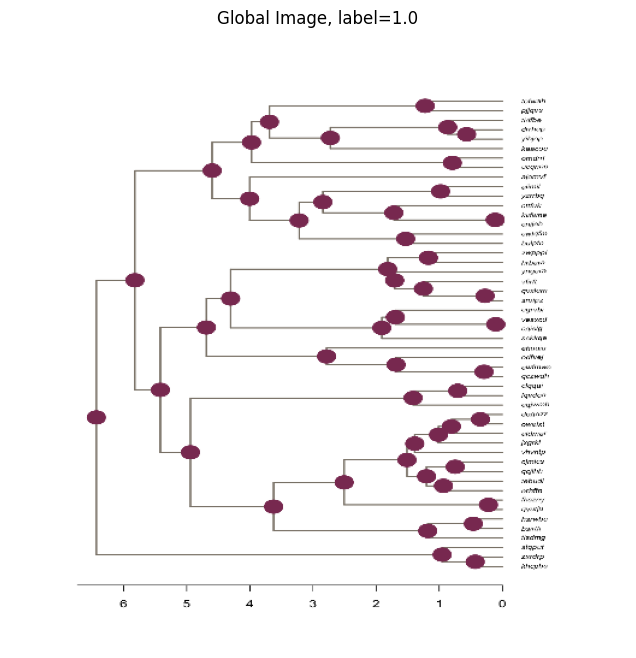

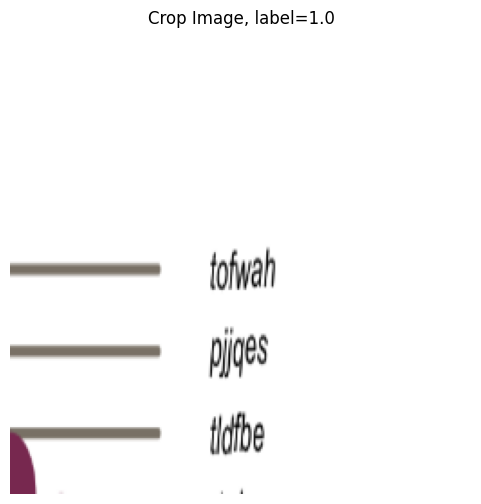

In [79]:
global_img, crop_img, geo_feats, label = train_dataset[0]

print("=== Item 0 du train_dataset ===")
print(f"Global image : type={type(global_img)}, shape={global_img.shape}, dtype={global_img.dtype}")
print(f"Crop image   : type={type(crop_img)}, shape={crop_img.shape}, dtype={crop_img.dtype}")
print(f"Geo features : {geo_feats} type={type(global_img)}, shape={geo_feats.shape}, dtype={geo_feats.dtype})")
print(f"Label        : {label} type={type(global_img)}, shape={label.shape}, dtype={label.dtype})")

plt.figure(figsize=(8,8))
plt.imshow(global_img.permute(1,2,0).numpy()) # C,H,W -> H,W,C
plt.title(f"Global Image, label={label.item()}")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(crop_img.permute(1,2,0).numpy())
plt.title(f"Crop Image, label={label.item()}")
plt.axis("off")
plt.show()

In [80]:
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2, # 0 pour cpu et éviter les deadlocks
    pin_memory=True # False pour cpu
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2, # 0 pour cpu et éviter les deadlocks
    pin_memory=True # False pour cpu
)

In [81]:
geo_feat_dim = train_dataset[0][2].shape[0]
print(f"geo_feat_dim={geo_feat_dim}")

geo_feat_dim=12


In [82]:
model = PhyloLabelClassifier(geo_feat_dim=geo_feat_dim)

In [83]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
history = train_model(model, train_loader, val_loader, device=device, epochs=10)

Training: 100%|██████████| 3874/3874 [24:49<00:00,  2.60it/s]


Epoch 1/10 - Loss: 0.2404, Acc: 0.8992, F1: 0.9144 | TP: 16677, TN: 11185, FP: 2840, FN: 284


    Validation: 100%|██████████| 991/991 [06:13<00:00,  2.65it/s]


    Val - Loss: 0.2325, Acc: 0.8940, F1: 0.9067 | TP: 16677, TN: 11185, FP: 2840, FN: 284
Model saved to model_checkpoints/model_epoch1.pth.


Training:  87%|████████▋ | 3355/3874 [21:45<03:07,  2.77it/s]

In [58]:
torch.save(model.state_dict(), "labelling_model_weights.pth")

In [60]:
with open("labelling_model_history.pkl", "wb") as f:
    pickle.dump(history, f)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
model.load_state_dict(torch.load("labelling_model_weights.pth", map_location=device))

In [ ]:
with open("labelling_model_history.pkl", "rb") as f:
    history_loaded = pickle.load(f)

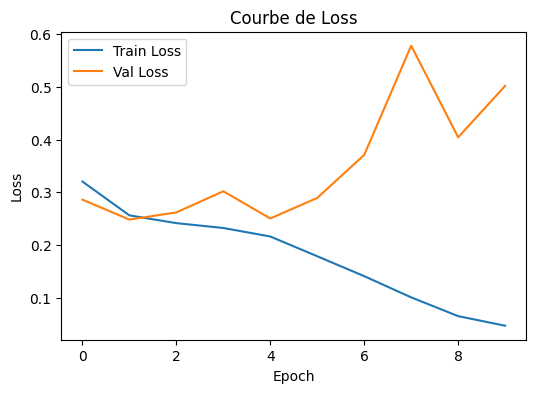

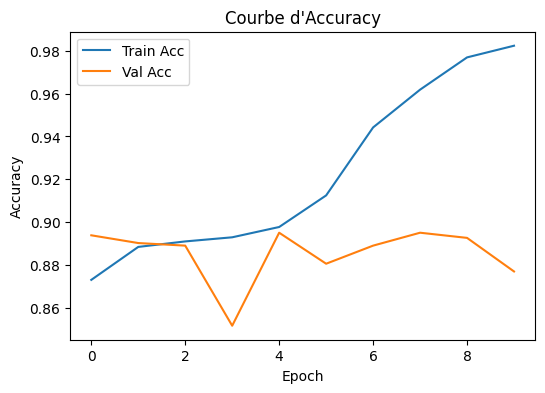

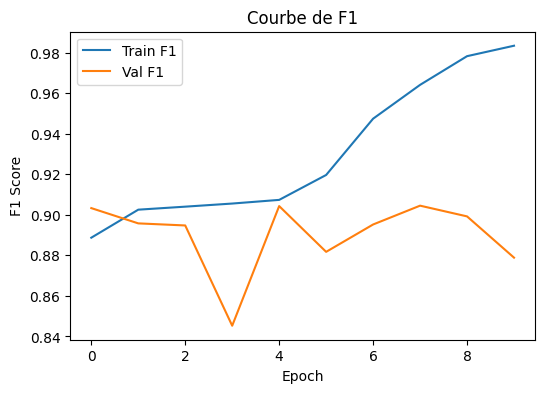

In [61]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbe de Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Courbe d'Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_f1"], label="Train F1")
plt.plot(history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Courbe de F1")
plt.legend()
plt.show()

### 2